In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
from scipy.interpolate import interp1d

In [3]:
x = np.arange(10001)
y = (np.sin(x*0.01*np.pi)*0.0025)

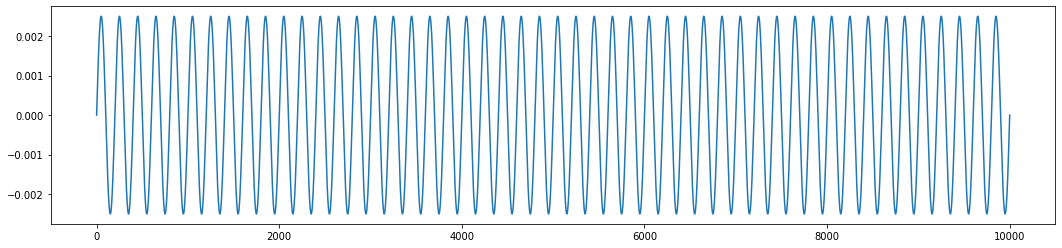

In [4]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(x,y)

In [5]:
f = interp1d(x,y)

In [6]:
noise = np.random.normal(0,0.0048,1000)

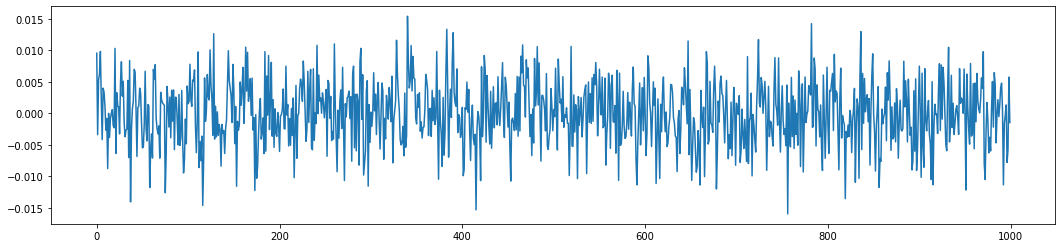

In [7]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(np.arange(1000),f(np.arange(1000)*(10000/1000))+noise)

In [8]:
def get_st(size,bias):
    x = np.arange((size*10)+1)
    y = (np.sin(x*(1/(size*10))*np.pi)*0.0025)
    noise = np.random.normal(0,0.0048,size)
    f = interp1d(x,y)
    return f(np.arange(size)*((10*size)/size))+noise +bias

In [9]:
l = get_st(1000,0.1)

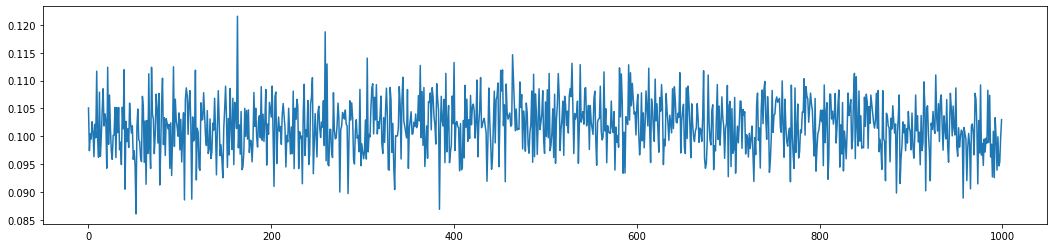

In [10]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(np.arange(len(l)),l)

### Sine

In [11]:
x = np.arange(10001)
y = np.sin(x*(1/10000)*np.pi)#*0.0025
noise_add = np.random.normal(0,0.0671,700)
noise_mul = np.random.normal(1,0.0671,700)

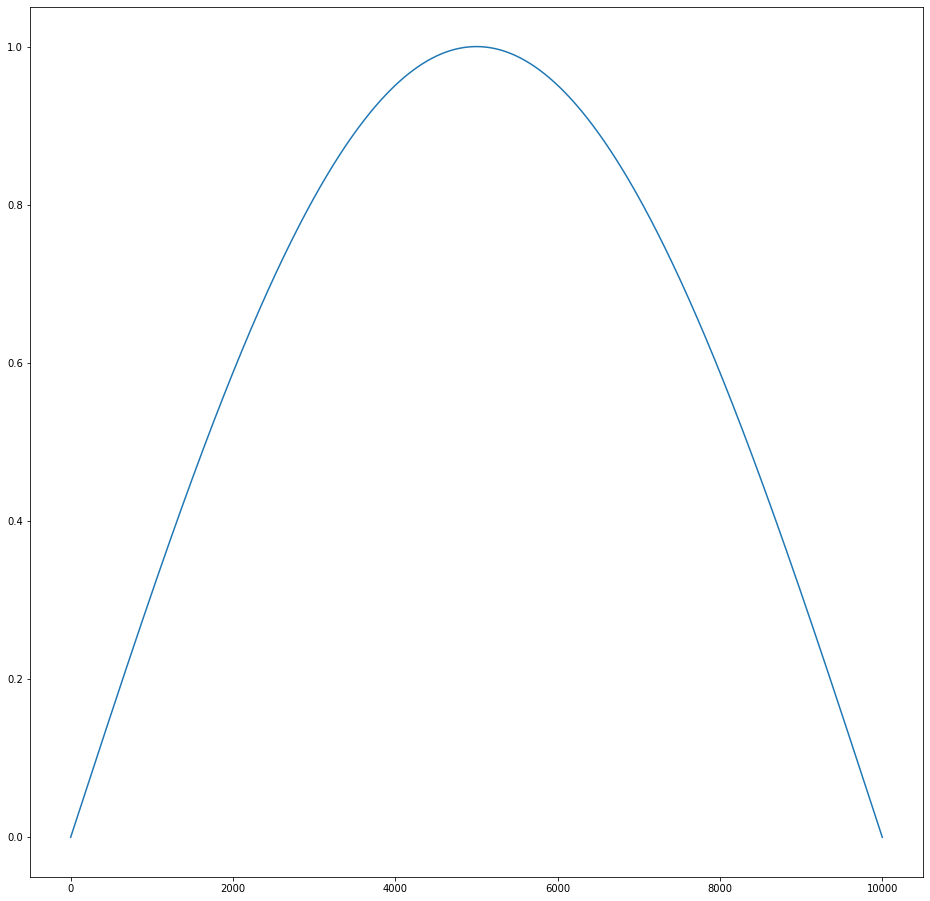

In [12]:
fig,ax = plt.subplots(figsize=(16,16))
ax.plot(x,y)

In [13]:
f = interp1d(x,y)

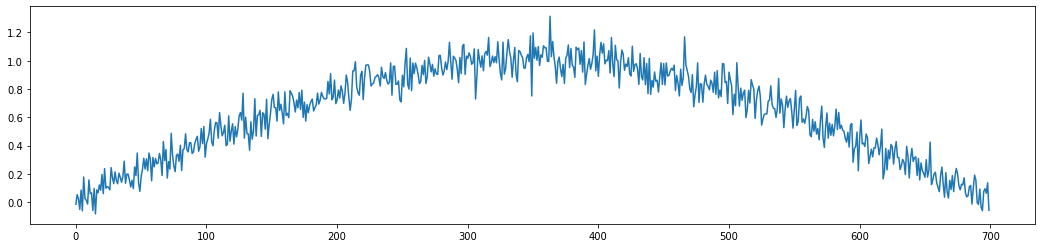

In [14]:
fig,ax = plt.subplots(figsize=(18 ,4))
ax.plot(np.arange(700),(f(np.arange(700)*(10000/700))+noise_add)*noise_mul)

# Line

In [15]:
x = np.arange(1001)/1000
y = np.arange(1001)/1000
noise_add = np.random.normal(0,0.0671,500)
noise_mul = np.random.normal(1,0.0671,500)

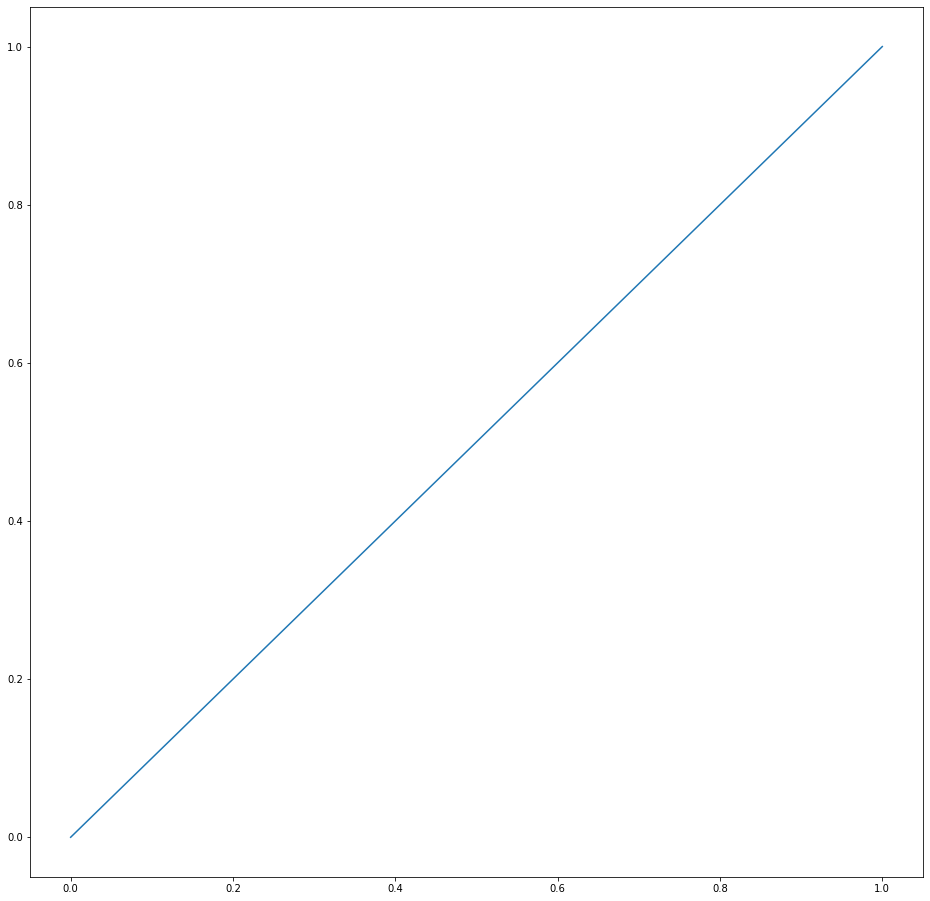

In [16]:
fig,ax = plt.subplots(figsize=(16,16))
ax.plot(x,y)

In [17]:
f = interp1d(x,y)

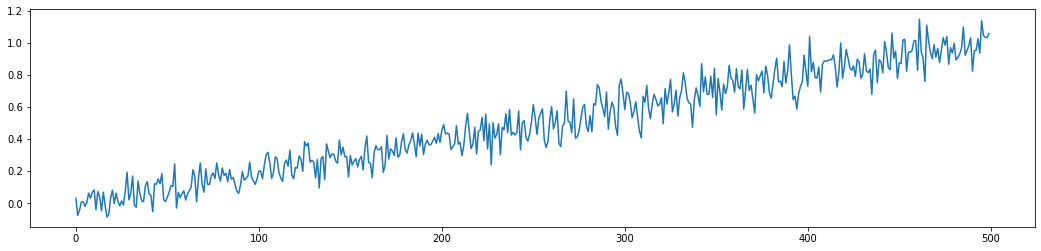

In [18]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(np.arange(500),(f(np.arange(500)*(1/500))+noise_add)*noise_mul)

### ABS

In [19]:
x = np.arange(-500,500)
y = -np.abs(x)
noise_add = np.random.normal(0,0.0671,500)
noise_mul = np.random.normal(1,0.0671,500)

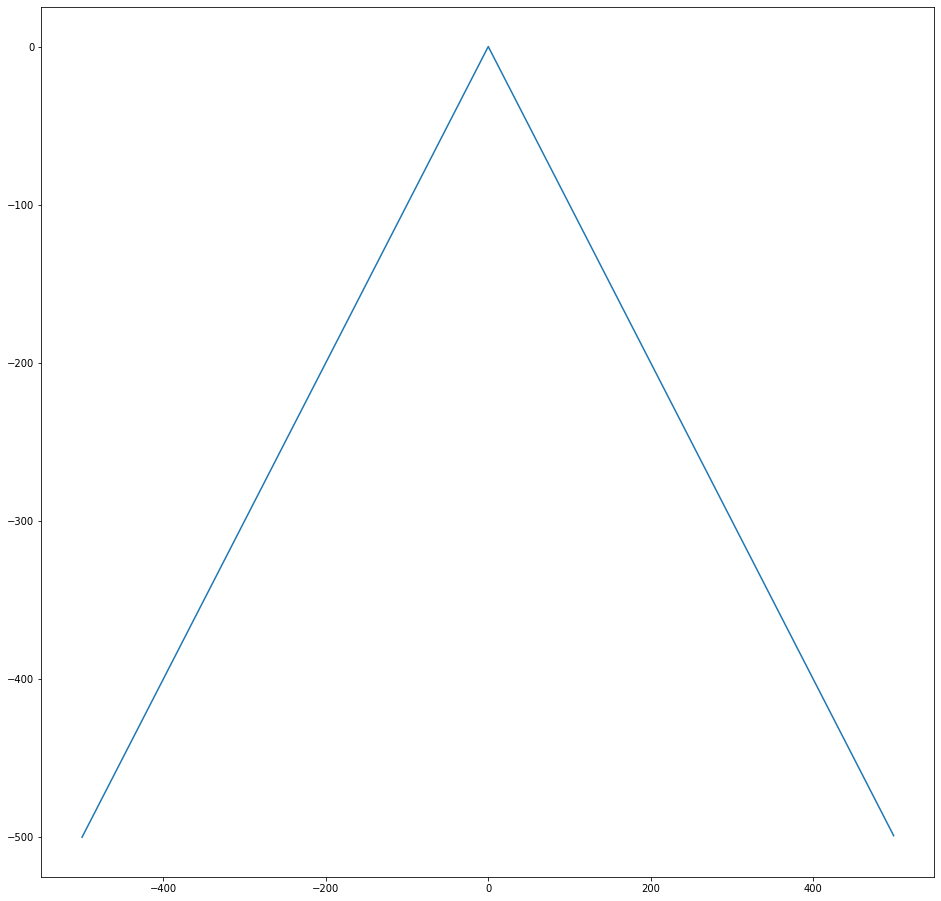

In [20]:
fig,ax = plt.subplots(figsize=(16,16))
ax.plot(x,y)

In [21]:
f = interp1d(x,y)

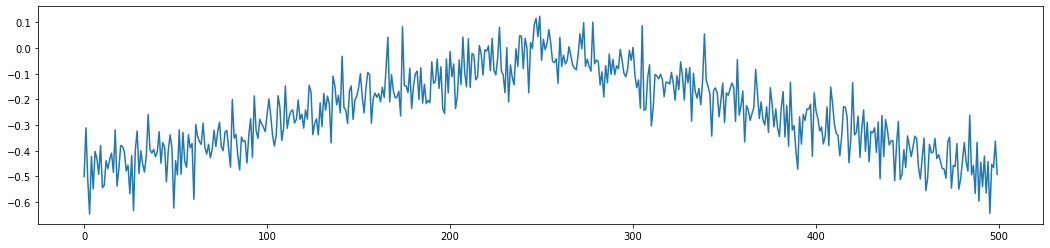

In [22]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(np.arange(500),(f(np.arange(-250,250)*(1/500))+noise_add)*noise_mul)

In [23]:
def get_abs(size,pcg=1,sign=1,scale=1,bias=0):
    x = np.linspace(-1,1,size)
    x = x[:int(pcg*len(x))]
    y = (sign)*np.abs(x)
    noise_add = np.random.normal(0,0.0071,len(y))
    noise_mul = np.random.normal(1,0.0071,len(y))
    return (((y+noise_add)*noise_mul)*scale) + bias

### X^2

In [24]:
x = np.arange(-500,500)
y = -np.power(x,2)
noise_add = np.random.normal(0,0.0271,500)
noise_mul = np.random.normal(1,0.0271,500)

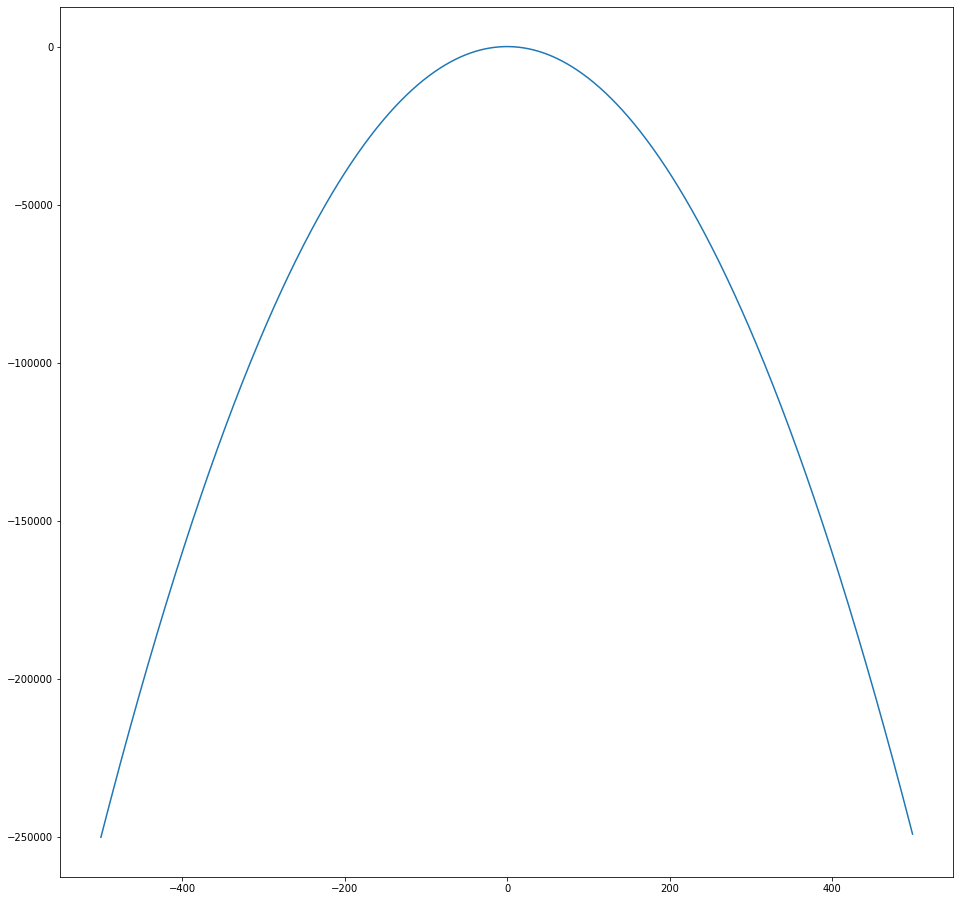

In [25]:
fig,ax = plt.subplots(figsize=(16,16))
ax.plot(x,y)

In [26]:
f = interp1d(x,y)

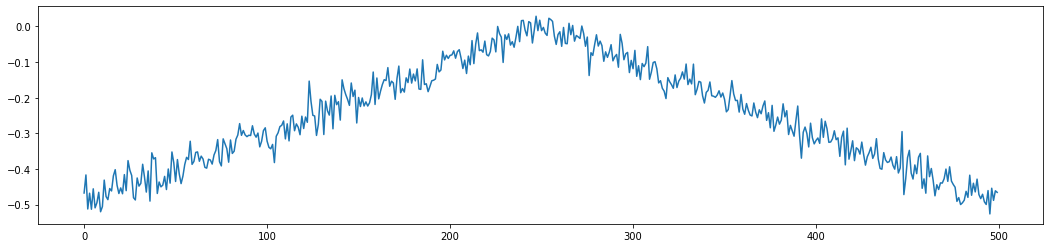

In [27]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(np.arange(500),(f(np.arange(-250,250)*(1/500))+noise_add)*noise_mul)

In [28]:
def get_turn(size,pcg=1,sign=1,scale=1,bias=1):
    x = np.linspace(-1,1,size)
    x = x[:int(pcg*len(x))]
    y = (sign)*np.power(x,2)
    noise_add = np.random.normal(0,0.0071,len(y))
    noise_mul = np.random.normal(1,0.0071,len(y))
    return (((y+noise_add)*noise_mul)*scale) + bias 

In [29]:
l = get_turn(500,pcg=1,sign=1,bias=0.4,scale=0.1)

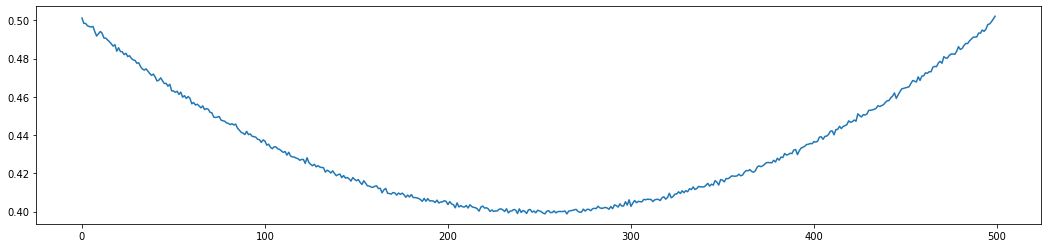

In [30]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(np.arange(len(l)),l)

In [31]:
max(l)

0.5020947557903771

### Square Tooth

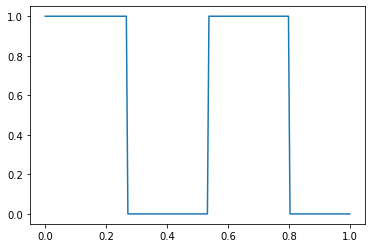

In [32]:
t = np.linspace(0, 1, 200)
data = ((signal.square(0.25 * np.pi * 15 * t)+1)*0.5 )
plt.plot(t, data)

In [33]:
d = get_abs(1000,pcg=0.5,sign=-1,bias=1,scale=0.4)
d_down = get_abs(1000,pcg=0.5,sign=-1,bias=0.6,scale=0.6)
d = np.concatenate([d,d_down])
data = ((signal.square(0.25 * np.pi * 10 * t)+1)*0.5 )

In [34]:
len(d)

1000

In [35]:
d[375-200:375] = d[375-200:375] * data

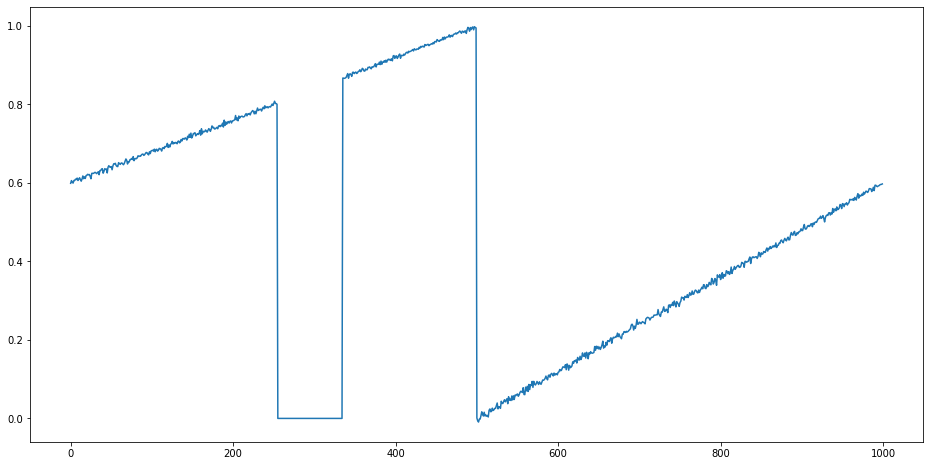

In [36]:
fig,ax = plt.subplots(figsize=(16,8))
ax.plot(np.arange(len(d)),d)

In [37]:
def get_switch(size,scale1=0.4,scale2 = 0.6):
    d = get_abs(size,pcg=0.5,sign=-1,bias=1,scale=scale1)
    d_down = get_abs(size,pcg=0.5,sign=-1,bias=scale2,scale=scale2)
    d = np.concatenate([d,d_down])
    
    t = np.linspace(0, 1, 200)
    data = ((signal.square(0.25 * np.pi * 10 * t)+1)*0.5 )
    
    d[(size//2)-200:(size//2)] = d[(size//2)-200:(size//2)] * data
    
    return d

In [38]:
l = get_switch(1000)

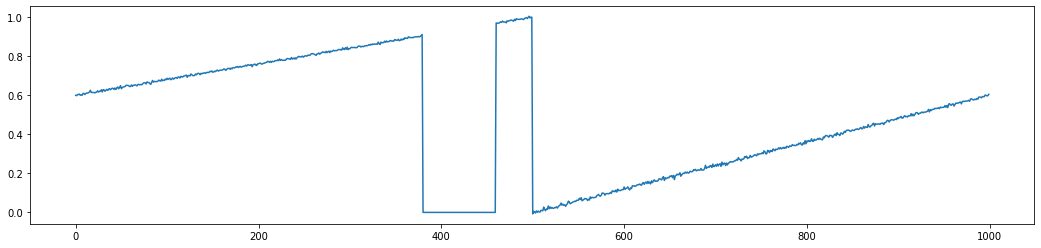

In [39]:
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(np.arange(len(l)),l)

# Generate

In [214]:
st1 = get_st(1200,0.5)
turn1 = get_abs(450,sign = -1,scale=0.2,bias=0.7)
st3 = get_st(100,0.5)
turn2 = get_abs(250,sign = 1,scale=0.22,bias=0.51-0.22)

st4 = get_st(2350,0.5)

turn3 = get_abs(380,sign = -1,scale=0.2,bias=0.7)
turn4 = get_abs(430,sign = 1,scale=0.22,bias=0.51-0.22)

switch1 = get_switch(800,scale1=0.5,scale2=0.45)

st5 = get_st(1800,0.52)
turn6 = get_abs(800,sign = 1,scale=0.4,bias=0.4-0.3)
st6 = get_st(2000,0.48)
turn7 = get_abs(600,sign = 1,scale=0.18,bias=0.4-0.18)

switch2 = get_switch(1200,scale1=0.6,scale2=0.55)
st7 = get_st(2000,0.55)
switch3 = get_switch(1800,scale1=0.45,scale2=0.45)

st8 = get_st(8000,0.5)

total = np.concatenate([st1,turn1,st3,turn2,st4,turn3,turn4,switch1,st5,turn6,st6,turn7,switch2,st7,switch3,st8])

In [215]:
len(total)

24160

In [216]:
total = np.clip(total,0,1)

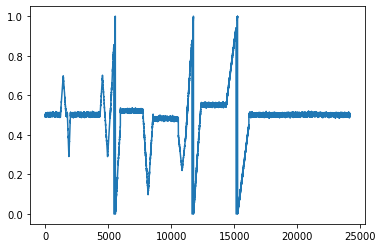

In [217]:
fig,ax = plt.subplots()
#plt.xticks([],total)
#plt.yticks([],total)
ax.plot(np.arange(len(total)),total)

In [84]:
#fig.savefig('Documents/synthesizedVis2.png')

In [218]:
c=0
for i in total:
    c+=1
    np.save(f'../dataset/fuz attack/generated_ds/v3/train/imag_{c}.npy',i)

In [219]:
f = interp1d(range(len(total)),total)

In [220]:
len(total)

24160

In [221]:
a=[]
for j in range(0,len(total)):
    a.append(f(j))

In [222]:
len(a)

24160

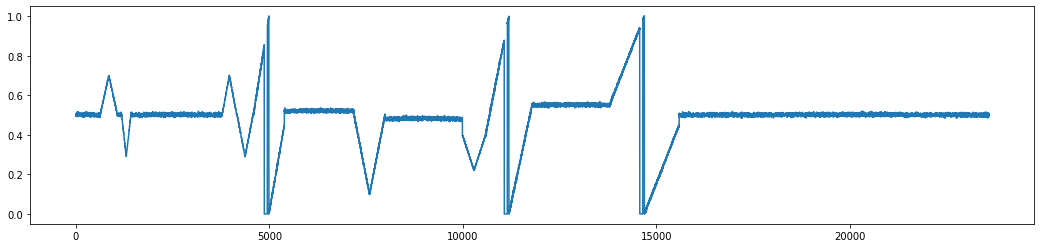

In [223]:
b = a[570:]
fig,ax = plt.subplots(figsize=(18,4))
ax.plot(np.arange(len(b)),b)

In [224]:
a = f(np.linspace(0,1,836)*6439)*4

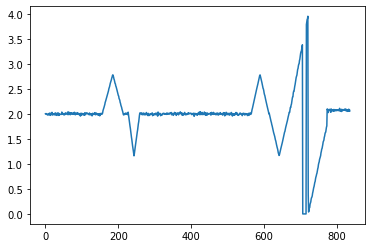

In [227]:
plt.plot(list(a))

In [65]:
np.save('../dataset/fuz attack/generated_ds/array_v2.npy',a)